### READ ME

Use the code blocks below to answer each question. Only print the output required for each question. Do not edit the comments at the top of each code cell. Otherwise, the auto-grader may misinterpret your results. See Question 0 as an example of how to complete a task (leave it in your notebook; don't delete it).

**Important: Working with DataFrames**

Throughout this assignment, you will progressively clean and transform data. Here's how to think about which DataFrame to use:

- **Questions 1-7**: Work with the main DataFrame `df` that you'll progressively clean (handling missing values, dates, binning, etc.)
- **Questions 8-15**: Create a NEW DataFrame called `df_model` (a copy of `df`) for the two-class model
- **Questions 16-19**: Continue using the original `df` to prepare for multi-class modeling
- **Questions 20-27**: Create a NEW DataFrame called `df_model` (a copy of the cleaned `df`) for the multi-class model

**General Rule**: If a question explicitly says "create a copy" or "create a new DataFrame," do it. Otherwise, continue working with your existing DataFrame. Each modeling section (two-class and multi-class) needs its own `df_model` because they use different labels.

In [54]:
# from google.colab import drive
# drive.mount('/content/drive')

### Question 0

Create a DataFrame with three rows and four columns. Name the columns 'Col1', 'Col2', 'Col3', 'Col4'. Create an index for the DataFrame and give the rows the index values of 'Row1', 'Row2', 'Row3'. Place a value in each column equal to the {ColumnName/RowName}. e.g. Col1/Row1. Print the entire DataFrame.

In [55]:
# Question 0

import pandas as pd

df = pd.DataFrame(columns=['Col1', 'Col2', 'Col3', 'Col4'], index=['Row1', 'Row2', 'Row3'])

for col in df:
  for i, value in df[col].items():
    df.at[i, col] = f'{i}/{col}'

df

,Col1,Col2,Col3,Col4
Row1,Row1/Col1,Row1/Col2,Row1/Col3,Row1/Col4
Row2,Row2/Col1,Row2/Col2,Row2/Col3,Row2/Col4
Row3,Row3/Col1,Row3/Col2,Row3/Col3,Row3/Col4


## **Data Import**

### Question 1

Import the data file 'student_enrollment_sample.csv' posted with this assignment. This file contains real data from a large online university in the United States. The identifying information has been deleted or randomized to maintain anonymity according to FERPA requirements. 

This university wants to help their students succeed. However, many students drop out for various reasons—some feel hopeless, helpless, or lost. The university wants to identify currently active students who are likely to drop in the near future so they can intervene and provide additional support. Your task is to create a predictive model to classify at-risk students for targeted interventions by the advisement center.

Print the shape of the dataset (rows and columns), then print the first five records.

**Answer this question in the LMS: How many students are in this sample?**

In [56]:
# Question 1

import pandas as pd

df_original = pd.read_csv('student_enrollment_sample.csv')

print(df_original.shape)
print(f'Answer: {df_original.shape[0]}')
df_original.head()


(50001, 35)
Answer: 50001


,EXPECTED_START_DATE,GRADUATION_DATE,ENROLL_COUNT,NUMBER_AVERAGE,MINUTES_ATTENDED,HOURS_ATTEMPTED,HOURS_EARNED,AR_BALANCE_AMOUNT,MINUTES_ABSENT,DAYS_ABSENT,...,CREDITS_LEFT,ENROLLMENT_COUNT,MODS_ATTENDED_COUNT,HS_GRADUATED_FLAG,DISABLED_FLAG,HISPANIC_FLAG,VETERAN_FLAG,STATUS_DESCRIPTION,IN_SCHOOL_FLAG,SIMPLE_STATUS_DESCRIPTION
0,NaN,NaN,1.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Application Cancelled,0.0,Other
1,NaN,2/8/2016,1.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Applicant,0.0,Other
2,NaN,NaN,1.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,...,180.0,2.0,0.0,0.0,0.0,0.0,0.0,Pending Applicant - Portal Only,0.0,Other
3,NaN,NaN,1.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,...,60.0,3.0,0.0,0.0,0.0,1.0,0.0,Applicant,0.0,Other
4,NaN,NaN,1.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pending Applicant - Portal Only,0.0,Other


# **Two-Class Modeling**

## **Data Cleaning**

### Missing Values

### Question 2

Print a list of missing values for each column in the dataset.

HINT: Search for 'pandas .isna() example'

**Answer this question in the LMS: What is the maximum count of missing values in any single column?**

In [57]:
# Question 2

missing_counts = df_original.isna().sum()
print(missing_counts)
print(f'Answer: {missing_counts.max()}')


EXPECTED_START_DATE           1871
GRADUATION_DATE               1598
ENROLL_COUNT                     1
NUMBER_AVERAGE                   1
MINUTES_ATTENDED             16287
HOURS_ATTEMPTED                  1
HOURS_EARNED                     1
AR_BALANCE_AMOUNT                1
MINUTES_ABSENT               16297
DAYS_ABSENT                      1
MINUTES_MAKEUP               16297
REENTRY_NUMBER                   1
PROGRAM_GROUP                   14
BIRTH_DATE                    1361
LAST_ACTIVITY_DATE            4388
MOD_NUMBER                    1324
COHORT_YEAR                   1375
CUMMULATIVE_GPA              15550
CUMMULATIVE_GPA_POINTS       37157
CUMMULATIVE_GPA_CREDITS      37157
AR_BALANCE                    1323
ENROLLMENT_GPA                1322
CREDITS_ATTEMPTED             1323
CREDITS_EARNED                1323
CREDITS_REQUIRED              1336
CREDITS_LEFT                  1336
ENROLLMENT_COUNT              1323
MODS_ATTENDED_COUNT           1323
HS_GRADUATED_FLAG   

### Question 3

Make a copy of the original DataFrame to work with (in case you want to use the original again later). Iterate through the new DataFrame and remove any column that has more than 30% of its records missing. Print a summary of missing value percentages for each remaining column.

**Note**: Call this copy `df` and use it for all subsequent data cleaning tasks (Questions 3-7).

**Answer this question in the LMS: What is the percent missing for BIRTH_DATE? Enter the decimal number without converting it to a percent.**

In [58]:
# Question 3

df = df_original.copy()

for col in list(df.columns):
    if df[col].isna().mean() > 0.30:
        df = df.drop(columns=col)

missing_percents = df.isna().mean()
print(missing_percents)
print(f"Answer: {missing_percents['BIRTH_DATE']}")


EXPECTED_START_DATE          0.037419
GRADUATION_DATE              0.031959
ENROLL_COUNT                 0.000020
NUMBER_AVERAGE               0.000020
HOURS_ATTEMPTED              0.000020
HOURS_EARNED                 0.000020
AR_BALANCE_AMOUNT            0.000020
DAYS_ABSENT                  0.000020
REENTRY_NUMBER               0.000020
PROGRAM_GROUP                0.000280
BIRTH_DATE                   0.027219
LAST_ACTIVITY_DATE           0.087758
MOD_NUMBER                   0.026479
COHORT_YEAR                  0.027499
AR_BALANCE                   0.026459
ENROLLMENT_GPA               0.026439
CREDITS_ATTEMPTED            0.026459
CREDITS_EARNED               0.026459
CREDITS_REQUIRED             0.026719
CREDITS_LEFT                 0.026719
ENROLLMENT_COUNT             0.026459
MODS_ATTENDED_COUNT          0.026459
HS_GRADUATED_FLAG            0.026459
DISABLED_FLAG                0.026459
HISPANIC_FLAG                0.026459
VETERAN_FLAG                 0.026459
STATUS_DESCR

### Question 4

Drop all remaining rows that contain any missing data. Print the number of rows and columns in the remaining dataset.

**Answer this question in the LMS: How many total columns are left (including both features and labels)?**

In [59]:
# Question 4

df = df.dropna()

print(df.shape)
print(f'Answer: {df.shape[1]}')


(44965, 29)
Answer: 29


### Handle Dates

### Question 5

Now it's time to handle the date values. LAST_ACTIVITY_DATE, EXPECTED_START_DATE, BIRTH_DATE, and GRADUATION_DATE may all be useful. We want to convert these date fields into numeric values.

For LAST_ACTIVITY_DATE, EXPECTED_START_DATE, and BIRTH_DATE, replace each date value with the number of days between that date and 2022-1-1. In other words: 2022-1-1 minus the date value in the field.

For GRADUATION_DATE, replace the date value with the number of days until graduation assuming that today's date is 2020-1-1. In other words, calculate: GRADUATION_DATE minus 2020-1-1.

Print the first five rows to examine the results.

**Answer this question in the LMS: How many days until record 1873 graduates (from the 2020-1-1 reference date)?**

In [60]:
# Question 5

reference_2022 = pd.Timestamp('2022-01-01')
reference_2020 = pd.Timestamp('2020-01-01')

for col in ['LAST_ACTIVITY_DATE', 'EXPECTED_START_DATE', 'BIRTH_DATE']:
    df[col] = (reference_2022 - pd.to_datetime(df[col])).dt.days

df['GRADUATION_DATE'] = (pd.to_datetime(df['GRADUATION_DATE']) - reference_2020).dt.days

print(f"Answer: {df.loc[1873, 'GRADUATION_DATE']}")
df.head()


Answer: 1572


,EXPECTED_START_DATE,GRADUATION_DATE,ENROLL_COUNT,NUMBER_AVERAGE,HOURS_ATTEMPTED,HOURS_EARNED,AR_BALANCE_AMOUNT,DAYS_ABSENT,REENTRY_NUMBER,PROGRAM_GROUP,...,CREDITS_LEFT,ENROLLMENT_COUNT,MODS_ATTENDED_COUNT,HS_GRADUATED_FLAG,DISABLED_FLAG,HISPANIC_FLAG,VETERAN_FLAG,STATUS_DESCRIPTION,IN_SCHOOL_FLAG,SIMPLE_STATUS_DESCRIPTION
1873,236,1572,1.0,0.0,0.0,0.0,0.0,0.0,0.0,GAGAB,...,183.0,2.0,1.0,0.0,0.0,0.0,0.0,Future Start,0.0,Other
1874,236,1544,1.0,0.0,0.0,0.0,0.0,0.0,0.0,BUBAB,...,180.0,1.0,0.0,0.0,0.0,0.0,0.0,Applicant,0.0,Other
1875,236,1544,1.0,0.0,0.0,0.0,0.0,0.0,0.0,BUBAB,...,180.0,1.0,0.0,0.0,0.0,0.0,0.0,Applicant,0.0,Other
1876,236,1040,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MSMAA,...,95.0,1.0,1.0,0.0,0.0,0.0,0.0,Future Start,0.0,Other
1878,236,1040,1.0,0.0,0.0,0.0,0.0,0.0,0.0,MSMAA,...,95.0,1.0,0.0,0.0,0.0,0.0,0.0,Applicant,0.0,Other


### Bin Categorical Values

### Question 6

The PROGRAM_GROUP feature indicates which academic program the student is enrolled in. Some programs are very small and represent less than 5% of the data. We need to bin those small programs into a new value called "Other".

Start by printing a list of PROGRAM_GROUP values divided by the total number of records to see what percent of cases they represent. Then, use a vectorized approach to change every program value to "Other" if it does not belong to a PROGRAM_GROUP that represents at least 5% of cases. Finally, print the new list of PROGRAM_GROUP values (including the new 'Other') to verify your routine worked correctly. You do not need to print the values in percent format—the original decimal values are fine.

**Answer this question in the LMS: Which program has the most students enrolled? Copy and paste the five-letter acronym.**

In [61]:
# Question 6

program_props = df['PROGRAM_GROUP'].value_counts(normalize=True)
print(program_props)
print(f'Answer: {program_props.idxmax()}')

large_programs = program_props[program_props >= 0.05].index
df['PROGRAM_GROUP'] = df['PROGRAM_GROUP'].where(df['PROGRAM_GROUP'].isin(large_programs), 'Other')

print(df['PROGRAM_GROUP'].value_counts(normalize=True))


PROGRAM_GROUP
GAGAB    0.282220
MSMAA    0.238341
HSHMB    0.140576
CSSMB    0.102791
CSCNB    0.099944
BUBAB    0.097209
GAWDB    0.020282
ACACB    0.009986
RTRCB    0.001979
BUBUA    0.001623
CSISM    0.001179
NUNUB    0.000912
MSMSA    0.000801
BUBUD    0.000512
HSSTA    0.000378
CSCNA    0.000334
RTRTA    0.000267
NUNEA    0.000156
GAGAA    0.000133
BUBMA    0.000133
NUNAM    0.000111
BUBAM    0.000044
CSNIB    0.000022
NUNEM    0.000022
HSPHM    0.000022
HSHAM    0.000022
Name: proportion, dtype: float64
Answer: GAGAB
PROGRAM_GROUP
GAGAB    0.282220
MSMAA    0.238341
HSHMB    0.140576
CSSMB    0.102791
CSCNB    0.099944
BUBAB    0.097209
Other    0.038919
Name: proportion, dtype: float64


### Relabel Label

### Question 7

Print the first five records of a filtered version of the DataFrame including only the 'IN_SCHOOL_FLAG' and 'STATUS_DESCRIPTION' columns where STATUS_DESCRIPTION equals 'Graduate'. Notice that all graduates have an 'IN_SCHOOL_FLAG' of zero, which makes them appear the same as students who have dropped out or been terminated. Because we want students to graduate, we need to treat graduates the same as active students. 

Convert the 'IN_SCHOOL_FLAG' value for all graduates to 1 (or 1.0). In addition, convert their 'SIMPLE_STATUS_DESCRIPTION' to 'Active'.

After making these changes, calculate and print the proportion of students who are "IN_SCHOOL".

**Answer this question in the LMS: What proportion of students are IN_SCHOOL (IN_SCHOOL_FLAG = 1.0)? Enter the decimal value without converting to a percent.**

In [62]:
# Question 7

graduate_rows = df.loc[df['STATUS_DESCRIPTION'] == 'Graduate', ['IN_SCHOOL_FLAG', 'STATUS_DESCRIPTION']]
print(graduate_rows.head())

df.loc[df['STATUS_DESCRIPTION'] == 'Graduate', 'IN_SCHOOL_FLAG'] = 1.0
df.loc[df['STATUS_DESCRIPTION'] == 'Graduate', 'SIMPLE_STATUS_DESCRIPTION'] = 'Active'

in_school_proportion = df['IN_SCHOOL_FLAG'].mean()
print(f'Answer: {in_school_proportion}')


       IN_SCHOOL_FLAG STATUS_DESCRIPTION
12890             0.0           Graduate
17734             0.0           Graduate
21039             0.0           Graduate
21607             0.0           Graduate
21931             0.0           Graduate
Answer: 0.1648615589903258


## **Classification Modeling**

### Dummy Coding

### Question 8

Import the packages necessary for DecisionTreeClassifier and train_test_split. We will use these later. For now, create another copy of the latest DataFrame to work from. Using the new copy, convert MOD_NUMBER and COHORT_YEAR to 'object' data types—these values are numbers, but they represent categorical values (which month and which year). Drop STATUS_DESCRIPTION and SIMPLE_STATUS_DESCRIPTION from the new DataFrame since those are alternative labels and we are going to use IN_SCHOOL_FLAG as the two-class label for our first model. Create dummy codes for all remaining categorical features in the new DataFrame. Print the first five records of the new DataFrame. There should be no remaining categorical values and many new dummy code features.

**Note**: Call this copy `df_model`. This is a separate DataFrame for modeling—you'll still have the original `df` available for the multi-class section later.

**Answer this question in the LMS: How many total columns does df_model have after creating dummy codes? (This represents all features plus the label)**

In [63]:
# Question 8

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz

df_model = df.copy()
df_model['MOD_NUMBER'] = df_model['MOD_NUMBER'].astype('object')
df_model['COHORT_YEAR'] = df_model['COHORT_YEAR'].astype('object')
df_model = df_model.drop(columns=['STATUS_DESCRIPTION', 'SIMPLE_STATUS_DESCRIPTION'])
df_model = pd.get_dummies(df_model, drop_first=False)

print(f'Answer: {df_model.shape[1]}')
df_model.head()


Answer: 48


,EXPECTED_START_DATE,GRADUATION_DATE,ENROLL_COUNT,NUMBER_AVERAGE,HOURS_ATTEMPTED,HOURS_EARNED,AR_BALANCE_AMOUNT,DAYS_ABSENT,REENTRY_NUMBER,BIRTH_DATE,...,MOD_NUMBER_9.0,MOD_NUMBER_10.0,MOD_NUMBER_11.0,MOD_NUMBER_12.0,MOD_NUMBER_13.0,COHORT_YEAR_2022.0,COHORT_YEAR_2023.0,COHORT_YEAR_2024.0,COHORT_YEAR_2025.0,COHORT_YEAR_2026.0
1873,236,1572,1.0,0.0,0.0,0.0,0.0,0.0,0.0,12991,...,False,False,False,False,False,False,False,False,False,True
1874,236,1544,1.0,0.0,0.0,0.0,0.0,0.0,0.0,236,...,False,False,False,False,False,False,False,False,False,True
1875,236,1544,1.0,0.0,0.0,0.0,0.0,0.0,0.0,15512,...,False,False,False,False,False,False,False,False,False,True
1876,236,1040,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7221,...,False,False,False,False,False,False,False,True,False,False
1878,236,1040,1.0,0.0,0.0,0.0,0.0,0.0,0.0,7298,...,False,False,False,False,False,False,False,True,False,False


### Select Label and Features

### Question 9

Set the y and X variables to represent the label and feature set. Use IN_SCHOOL_FLAG as the label (y) and all other columns as features (X). Print the first five records of the feature list to verify it looks correct.

**Answer this question in the LMS: How many features (columns) are in the X DataFrame?**

In [64]:
# Question 9

y = df_model['IN_SCHOOL_FLAG']
X = df_model.drop(columns=['IN_SCHOOL_FLAG'])

print(X.head())
print(f'Answer: {X.shape[1]}')


      EXPECTED_START_DATE  GRADUATION_DATE  ENROLL_COUNT  NUMBER_AVERAGE  \
1873                  236             1572           1.0             0.0   
1874                  236             1544           1.0             0.0   
1875                  236             1544           1.0             0.0   
1876                  236             1040           1.0             0.0   
1878                  236             1040           1.0             0.0   

      HOURS_ATTEMPTED  HOURS_EARNED  AR_BALANCE_AMOUNT  DAYS_ABSENT  \
1873              0.0           0.0                0.0          0.0   
1874              0.0           0.0                0.0          0.0   
1875              0.0           0.0                0.0          0.0   
1876              0.0           0.0                0.0          0.0   
1878              0.0           0.0                0.0          0.0   

      REENTRY_NUMBER  BIRTH_DATE  ...  MOD_NUMBER_9.0  MOD_NUMBER_10.0  \
1873             0.0       12991  ...     

### Split Data

### Question 10

Split the y and X sets into training and testing sets. Do a 70/30 split, meaning 70% training data. Use a random seed of 12345. Print the shape of the X_train dataset to verify the split.

**Answer this question in the LMS: What is the number of rows in X_train?**

In [65]:
# Question 10

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=12345
)

print(X_train.shape)
print(f'Answer: {X_train.shape[0]}')


(31475, 47)
Answer: 31475


### Create Classifier and Fit Model

### Question 11

Create and fit a DecisionTreeClassifier() model using the training datasets. Use a random_state of 12345 for reproducibility. Print the maximum depth of the trained tree.

**Answer this question in the LMS: What is the maximum depth of the decision tree? This indicates how many levels of splits the tree made.**

In [66]:
# Question 11

clf = DecisionTreeClassifier(random_state=12345)
clf.fit(X_train, y_train)

print(clf.get_depth())
print(f'Answer: {clf.get_depth()}')


23
Answer: 23


### Compare Actual Versus Predicted Values

### Question 12

Generate predictions for the testing dataset. Add the predicted values to a new DataFrame along with the actual values and print the first 10 records.

**Answer this question in the LMS: How many of the first 10 records/predictions are inaccurate?**

In [67]:
# Question 12

y_pred = clf.predict(X_test)

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(f"Answer: {(comparison_df.head(10)['Actual'] != comparison_df.head(10)['Predicted']).sum()}")
comparison_df.head(10)


Answer: 0


,Actual,Predicted
2148,0.0,0.0
22511,0.0,0.0
45412,0.0,0.0
16742,1.0,1.0
7689,0.0,0.0
22725,0.0,0.0
26189,0.0,0.0
39307,0.0,0.0
48033,0.0,0.0
23015,0.0,0.0


### Assess Model Fit/Quality/Accuracy

### Question 13

Generate a confusion matrix for the results. Use display_labels of ['Quit', 'Active'] to make the matrix more interpretable.

**Answer this question in the LMS: How many students are currently active (actual = 1.0) but predicted to quit (predicted = 0.0)?**

Answer: 131


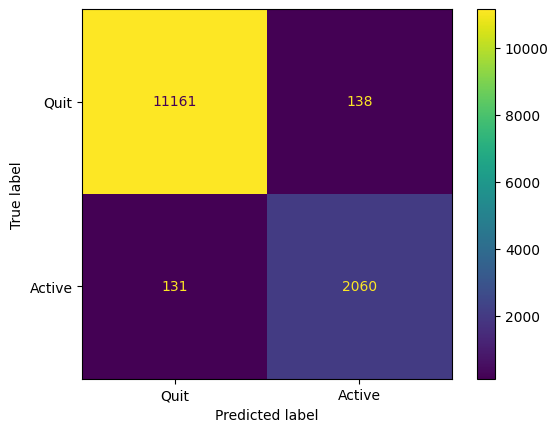

In [68]:
# Question 13

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0.0, 1.0])
print(f'Answer: {cm[1, 0]}')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Quit', 'Active']
)


### Question 14

Generate the accuracy, precision, recall, and F1 scores for the predictions. For precision, recall, and F1, specify that we're interested in predicting the "Active" class (pos_label=1.0).

**Answer this question in the LMS: What is the accuracy score? Do not convert it to a percent or round it.**

In [69]:
# Question 14

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1.0)
recall = recall_score(y_test, y_pred, pos_label=1.0)
f1 = f1_score(y_test, y_pred, pos_label=1.0)

print(accuracy)
print(precision)
print(recall)
print(f1)
print(f'Answer: {accuracy}')


0.9800593031875463
0.9372156505914467
0.9402099497946144
0.9387104123946229
Answer: 0.9800593031875463


### Visualize Classification Model

### Question 15

Generate a tree visualization using export_graphviz.

**Answer this question in the LMS: Which feature is most important in determining IN_SCHOOL_FLAG? Enter the name exactly as it appears in the dataset (including underscores and capitalization).**

In [70]:
# Question 15

root_feature = X.columns[clf.tree_.feature[0]]
print(f'Answer: {root_feature}')

try:
    import graphviz

    dot_data = export_graphviz(
        clf,
        out_file=None,
        feature_names=X.columns,
        class_names=['Quit', 'Active'],
        filled=True,
        rounded=True,
        special_characters=True
    )

    graphviz.Source(dot_data)
except ImportError:
    print('graphviz is not installed in this environment.')


Answer: MODS_ATTENDED_COUNT
graphviz is not installed in this environment.


# **Multi-Class Modeling**

## **Data Cleaning**

### Combine or Eliminate Low Frequency Values

### Question 16

The label 'IN_SCHOOL_FLAG' was ideal for a two-class classification model. However, most students are put on probation before they are terminated. Therefore, it could be useful to predict three distinct categories: Active, Probation, and Terminated. First, let's identify what label combinations exist across all three label-related columns. Print a list of all value combinations of 'STATUS_DESCRIPTION', 'IN_SCHOOL_FLAG', and 'SIMPLE_STATUS_DESCRIPTION' along with a count of how often each occurs.

**Note**: Use the original `df` DataFrame (not `df_model`) for this and the following multi-class preparation questions (16-19).

HINT: Consider using the .groupby() method of pandas to perform this in a single line of code. The purpose of this task is to explore your options for potential labels in this dataset. Each of these features represents current states for each student.

**Answer this question in the LMS: How many unique STATUS_DESCRIPTION values exist in the output table? This helps us understand the complexity of student statuses.**

In [71]:
# Question 16

summary_df = (
    df.groupby(['STATUS_DESCRIPTION', 'IN_SCHOOL_FLAG', 'SIMPLE_STATUS_DESCRIPTION'])
      .size()
      .reset_index(name='count')
)
print(summary_df)
print(f"Answer: {summary_df['STATUS_DESCRIPTION'].nunique()}")


             STATUS_DESCRIPTION  IN_SCHOOL_FLAG SIMPLE_STATUS_DESCRIPTION  \
0                        Active             1.0                    Active   
1               Active-Pre Grad             1.0                    Active   
2                     Applicant             0.0                     Other   
3         Application Cancelled             0.0                     Other   
4                        Cancel             0.0                Terminated   
5                     Dismissed             0.0                Terminated   
6                          Drop             0.0                Terminated   
7                False Re-Enter             0.0                Terminated   
8                   False Start             0.0                Terminated   
9                  Future Start             0.0                     Other   
10                     Graduate             1.0                    Active   
11                 NDS-Complete             0.0                     Other   

### Question 17

To simplify our eventual model, eliminate all records for students whose 'SIMPLE_STATUS_DESCRIPTION' equals 'Other'. Then, reprint the table above to ensure it worked properly.

**Answer this question in the LMS: After filtering out 'Other', how many unique combinations of STATUS_DESCRIPTION, IN_SCHOOL_FLAG, and SIMPLE_STATUS_DESCRIPTION remain?**

In [72]:
# Question 17

df = df[df['SIMPLE_STATUS_DESCRIPTION'] != 'Other']

summary_df = (
    df.groupby(['STATUS_DESCRIPTION', 'IN_SCHOOL_FLAG', 'SIMPLE_STATUS_DESCRIPTION'])
      .size()
      .reset_index(name='count')
)
print(summary_df)
print(f'Answer: {len(summary_df)}')


           STATUS_DESCRIPTION  IN_SCHOOL_FLAG SIMPLE_STATUS_DESCRIPTION  count
0                      Active             1.0                    Active   6585
1             Active-Pre Grad             1.0                    Active    287
2                      Cancel             0.0                Terminated   1633
3                   Dismissed             0.0                Terminated    203
4                        Drop             0.0                Terminated   1562
5              False Re-Enter             0.0                Terminated    460
6                 False Start             0.0                Terminated   4074
7                    Graduate             1.0                    Active    317
8                     No Show             0.0                Terminated  17229
9                   Probation             1.0                    Active    224
10  Transfer To Other Program             0.0                Terminated     53
Answer: 11


### Question 18

Next, eliminate anyone whose 'STATUS_DESCRIPTION' equals 'Transfer To Other Program', 'No Show', or 'False Start' since those outcomes are not relevant to students who were once active. Reprint the same summary table afterward.

**Answer this question in the LMS: After removing these three status types, how many total students remain in the dataset?**

In [73]:
# Question 18

df = df[~df['STATUS_DESCRIPTION'].isin(['Transfer To Other Program', 'No Show', 'False Start'])]

summary_df = (
    df.groupby(['STATUS_DESCRIPTION', 'IN_SCHOOL_FLAG', 'SIMPLE_STATUS_DESCRIPTION'])
      .size()
      .reset_index(name='count')
)
print(summary_df)
print(f'Answer: {len(df)}')


  STATUS_DESCRIPTION  IN_SCHOOL_FLAG SIMPLE_STATUS_DESCRIPTION  count
0             Active             1.0                    Active   6585
1    Active-Pre Grad             1.0                    Active    287
2             Cancel             0.0                Terminated   1633
3          Dismissed             0.0                Terminated    203
4               Drop             0.0                Terminated   1562
5     False Re-Enter             0.0                Terminated    460
6           Graduate             1.0                    Active    317
7          Probation             1.0                    Active    224
Answer: 11271


### Question 19

Finally, relabel the 'SIMPLE_STATUS_DESCRIPTION' of those whose 'STATUS_DESCRIPTION' equals 'Probation' to 'Probation'. This will create our three-class label: Active, Probation, and Terminated. Reprint the table.

**Answer this question in the LMS: How many students now have 'Probation' as their SIMPLE_STATUS_DESCRIPTION? This is our new third class for the multi-class model.**

In [74]:
# Question 19

df.loc[df['STATUS_DESCRIPTION'] == 'Probation', 'SIMPLE_STATUS_DESCRIPTION'] = 'Probation'

summary_df = (
    df.groupby(['STATUS_DESCRIPTION', 'IN_SCHOOL_FLAG', 'SIMPLE_STATUS_DESCRIPTION'])
      .size()
      .reset_index(name='count')
)
print(summary_df)
print(f"Answer: {(df['SIMPLE_STATUS_DESCRIPTION'] == 'Probation').sum()}")


  STATUS_DESCRIPTION  IN_SCHOOL_FLAG SIMPLE_STATUS_DESCRIPTION  count
0             Active             1.0                    Active   6585
1    Active-Pre Grad             1.0                    Active    287
2             Cancel             0.0                Terminated   1633
3          Dismissed             0.0                Terminated    203
4               Drop             0.0                Terminated   1562
5     False Re-Enter             0.0                Terminated    460
6           Graduate             1.0                    Active    317
7          Probation             1.0                 Probation    224
Answer: 224


## **Classification Modeling**

### Dummy Codes

### Question 20

Create a new copy of the DataFrame to work from. The features 'MOD_NUMBER' and 'COHORT_YEAR' represent categorical values that do not have an inherent order. Therefore, they should be treated as categories and cast to objects. Once you have done so, drop the alternative labels 'STATUS_DESCRIPTION' and 'IN_SCHOOL_FLAG' from the dataset because we will be predicting 'SIMPLE_STATUS_DESCRIPTION'. Then, generate dummy codes for the remaining categorical features (but NOT for SIMPLE_STATUS_DESCRIPTION since that's our label). Print the first five records to verify everything worked correctly.

**Note**: Call this copy `df_model` (yes, you can reuse this variable name from the two-class section). This creates a fresh modeling DataFrame for the multi-class model.

**Answer this question in the LMS: How many columns does df_model have after creating dummy codes? (This includes both features and the SIMPLE_STATUS_DESCRIPTION label)**

In [75]:
# Question 20

df_model = df.copy()
df_model['MOD_NUMBER'] = df_model['MOD_NUMBER'].astype('object')
df_model['COHORT_YEAR'] = df_model['COHORT_YEAR'].astype('object')

y = df_model['SIMPLE_STATUS_DESCRIPTION']
X = df_model.drop(columns=['STATUS_DESCRIPTION', 'IN_SCHOOL_FLAG', 'SIMPLE_STATUS_DESCRIPTION'])
X = pd.get_dummies(X, drop_first=False)

df_model = X.copy()
df_model['SIMPLE_STATUS_DESCRIPTION'] = y

print(f'Answer: {df_model.shape[1]}')
df_model.head()


Answer: 48


,EXPECTED_START_DATE,GRADUATION_DATE,ENROLL_COUNT,NUMBER_AVERAGE,HOURS_ATTEMPTED,HOURS_EARNED,AR_BALANCE_AMOUNT,DAYS_ABSENT,REENTRY_NUMBER,BIRTH_DATE,...,MOD_NUMBER_10.0,MOD_NUMBER_11.0,MOD_NUMBER_12.0,MOD_NUMBER_13.0,COHORT_YEAR_2022.0,COHORT_YEAR_2023.0,COHORT_YEAR_2024.0,COHORT_YEAR_2025.0,COHORT_YEAR_2026.0,SIMPLE_STATUS_DESCRIPTION
3274,264,1012,1.0,0.000000,0.0,0.0,9040.0,0.0,0.0,10429,...,False,False,False,False,False,False,True,False,False,Active
3275,264,1544,1.0,0.000000,0.0,0.0,8160.0,0.0,0.0,10920,...,False,False,False,False,False,False,False,False,True,Active
3280,264,956,1.0,85.130435,120.0,120.0,9040.0,0.0,0.0,7914,...,False,False,False,False,False,False,True,False,False,Active
3282,264,1012,1.0,0.000000,0.0,0.0,9040.0,0.0,0.0,7604,...,False,False,False,False,False,False,True,False,False,Active
3293,264,1544,1.0,0.000000,0.0,0.0,8160.0,0.0,0.0,13462,...,False,False,False,False,False,False,False,False,True,Active


### Select Label and Features

### Question 21

Create the y and X variables to store the label and features using 'SIMPLE_STATUS_DESCRIPTION' as the label. Print the unique values in y to verify the three classes.

**Answer this question in the LMS: How many unique classes are in y?**

In [76]:
# Question 21

y = df_model['SIMPLE_STATUS_DESCRIPTION']
X = df_model.drop(columns=['SIMPLE_STATUS_DESCRIPTION'])

print(y.unique())
print(f'Answer: {y.nunique()}')


<StringArray>
['Active', 'Terminated', 'Probation']
Length: 3, dtype: str
Answer: 3


### Split Data

### Question 22

Split the data using a 70/30 split and 12345 as the random seed. Print the shape of y_train to verify the split.

**Answer this question in the LMS: What is the number of samples in y_train? This represents 70% of the total dataset after filtering.**

In [77]:
# Question 22

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=12345
)

print(y_train.shape)
print(f'Answer: {y_train.shape[0]}')


(7889,)
Answer: 7889


### Create Classifier and Fit Model

### Question 23

Train a decision tree classifier model using the datasets you just generated. Use random_state=12345 for reproducibility. Print the number of classes the model learned. You may need to ask AI or Google to help you learn how to print the number of classes learned.

**Answer this question in the LMS: How many classes did the model learn?**

In [78]:
# Question 23

clf = DecisionTreeClassifier(random_state=12345)
clf.fit(X_train, y_train)

print(len(clf.classes_))
print(f'Answer: {len(clf.classes_)}')


3
Answer: 3


### Compare Actual Versus Predicted Values

### Question 24

Predict the y values for the testing dataset and add them to a DataFrame along with the actual y values for comparison. Print the first 20 records.

**Answer this question in the LMS: How many of these first 20 predictions were inaccurate?**

In [79]:
# Question 24

y_pred = clf.predict(X_test)

comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(f"Answer: {(comparison_df.head(20)['Actual'] != comparison_df.head(20)['Predicted']).sum()}")
comparison_df.head(20)


Answer: 3


,Actual,Predicted
17237,Active,Active
15035,Active,Active
18248,Terminated,Terminated
9492,Active,Active
46266,Probation,Terminated
3394,Active,Active
29770,Active,Terminated
41249,Terminated,Terminated
39809,Active,Active
20634,Active,Active


### Assess Model Fit/Quality/Accuracy

### Question 25

Generate and print a confusion matrix to view the results. The confusion matrix will show how well the model distinguishes between Active, Probation, and Terminated students.

**Answer this question in the LMS: In a multi-class confusion matrix, which class is the model best at predicting correctly?**

Answer: Active


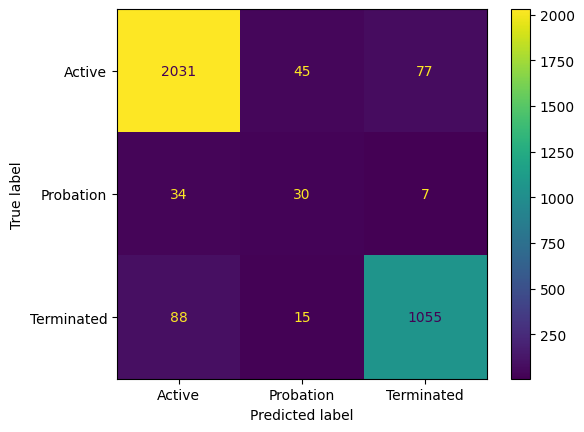

In [80]:
# Question 25

cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
best_class = clf.classes_[cm.diagonal().argmax()]
print(f'Answer: {best_class}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)


### Question 26

Generate the fit metrics (accuracy, precision, recall, F1) for the multi-class model. Use 'weighted' averaging to account for class imbalance, which gives each class's metric a weight based on how many samples are in that class.

**Answer this question in the LMS: What is the weighted precision score? Enter the full decimal value without rounding. This metric tells us what proportion of students predicted for each class actually belong to that class.**

In [81]:
# Question 26

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(accuracy)
print(precision)
print(recall)
print(f1)
print(f'Answer: {precision}')


0.9213483146067416
0.9246793132815763
0.9213483146067416
0.9228817939805212
Answer: 0.9246793132815763


### Visualize Classification Model

### Question 27

Generate a decision tree visualization using export_graphviz.

**Answer this question in the LMS: Which feature is most important in this multi-class model predicting 'SIMPLE_STATUS_DESCRIPTION' if MODS_ATTENDED_COUNT is less than or equal to 4.5? Enter the name exactly as it appears including underscores and capitalization.**

In [82]:
# Question 27

left_child_index = clf.tree_.children_left[0]
left_branch_feature = X.columns[clf.tree_.feature[left_child_index]]
print(f'Answer: {left_branch_feature}')

try:
    import graphviz

    dot_data = export_graphviz(
        clf,
        out_file=None,
        feature_names=X.columns,
        class_names=clf.classes_,
        filled=True,
        rounded=True,
        special_characters=True
    )

    graphviz.Source(dot_data)
except ImportError:
    print('graphviz is not installed in this environment.')


Answer: EXPECTED_START_DATE
graphviz is not installed in this environment.
